<a href="https://colab.research.google.com/github/tomzavi56/SA-Development-Analysis/blob/main/notebooks/sa_development_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Poverty data shape: (160, 80)
Unemployment data shape: (234, 74)
   REF_AREA_LABEL  year  poverty_pct
20   South Africa  2005         57.5
23   South Africa  2008         55.7
25   South Africa  2010         45.8
29   South Africa  2014         46.7
37   South Africa  2022         37.9
   REF_AREA_LABEL  year  unemployment_pct
25   South Africa  2016            26.536
26   South Africa  2017            27.035
27   South Africa  2018            26.906
28   South Africa  2019            28.468
29   South Africa  2020            29.217
30   South Africa  2021            34.007
31   South Africa  2022            33.268
32   South Africa  2023            32.098
33   South Africa  2024            32.279
34   South Africa  2025            32.391


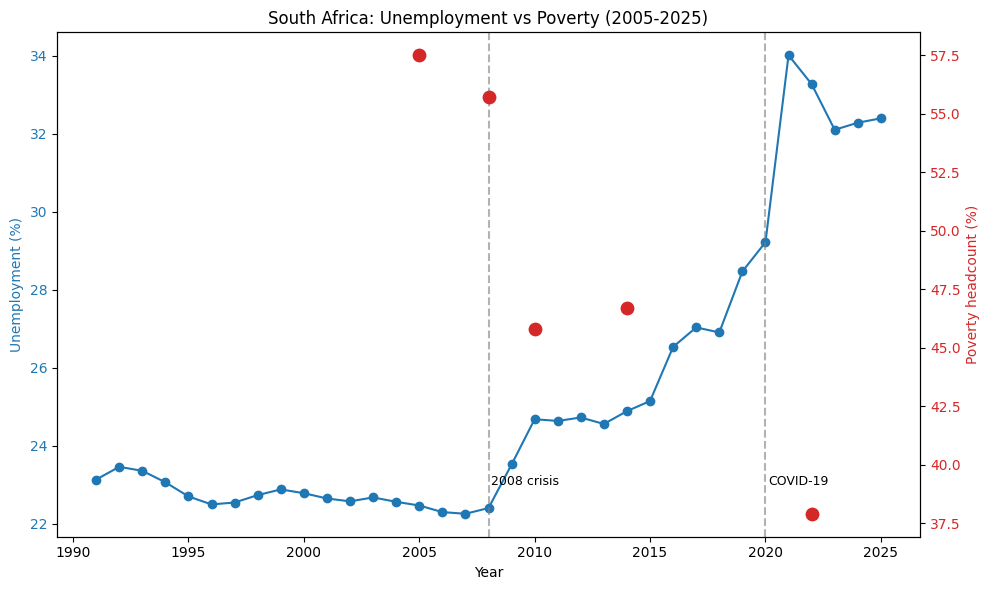

In [6]:
import pandas as pd

#Load my data set from Github using url
poverty_url = "https://raw.githubusercontent.com/tomzavi56/SA-Development-Analysis/main/data/raw/poverty_headcount.csv"
unemployment_url = "https://raw.githubusercontent.com/tomzavi56/SA-Development-Analysis/main/data/raw/unemployment.csv"

poverty = pd.read_csv(poverty_url)
unemployment = pd.read_csv(unemployment_url)

print("Poverty data shape:", poverty.shape)
print("Unemployment data shape:", unemployment.shape)

# Filter to South Africa only
poverty_sa = poverty[poverty['REF_AREA_LABEL'] == 'South Africa']
unemployment_sa = unemployment[unemployment['REF_AREA_LABEL'] == 'South Africa']

# Identify year columns (they're the ones that are just numbers, e.g. "2008")
year_cols_poverty = [c for c in poverty.columns if c.isdigit()]
year_cols_unemployment = [c for c in unemployment.columns if c.isdigit()]

# Reshape to long format: one row per year
poverty_long = poverty_sa.melt(
    id_vars=['REF_AREA_LABEL'], value_vars=year_cols_poverty,
    var_name='year', value_name='poverty_pct'
).dropna()

unemployment_long = unemployment_sa.melt(
    id_vars=['REF_AREA_LABEL'], value_vars=year_cols_unemployment,
    var_name='year', value_name='unemployment_pct'
).dropna()

poverty_long['year'] = poverty_long['year'].astype(int)
unemployment_long['year'] = unemployment_long['year'].astype(int)

print(poverty_long)
print(unemployment_long.tail(10))

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Unemployment line (left axis)
ax1.plot(unemployment_long['year'], unemployment_long['unemployment_pct'],
         color='tab:blue', marker='o', label='Unemployment (%)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Unemployment (%)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Poverty points (right axis, since it's sparse)
ax2 = ax1.twinx()
ax2.scatter(poverty_long['year'], poverty_long['poverty_pct'],
            color='tab:red', s=80, label='Poverty headcount (%)', zorder=5)
ax2.set_ylabel('Poverty headcount (%)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Mark the two shocks
ax1.axvline(2008, color='gray', linestyle='--', alpha=0.6)
ax1.text(2008.1, 23, '2008 crisis', fontsize=9)
ax1.axvline(2020, color='gray', linestyle='--', alpha=0.6)
ax1.text(2020.1, 23, 'COVID-19', fontsize=9)

plt.title('South Africa: Unemployment vs Poverty (2005-2025)')
fig.tight_layout()
plt.savefig('unemployment_vs_poverty.png', dpi=150)
plt.show()
